In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Get sklearn! https://scikit-learn.org/stable/
from sklearn import linear_model

In [10]:
df_CO2 = pd.read_csv('/Users/siobhankassem/Desktop/USC/Classes/Fall 2026/Python Data Science/Datasets/ManuaLoa_CO2.csv')
df_EPA = pd.read_csv('/Users/siobhankassem/Desktop/USC/Classes/Fall 2026/Python Data Science/Datasets/LA_AQS_2023.csv') 

In [11]:
df_EPA.columns

Index(['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name',
       'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year',
       'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type',
       'Nonreg Observation Count', 'Observation Count', 'Observation Percent',
       'Nonreg Arithmetic Mean', 'Arithmetic Mean',
       'Nonreg First Maximum Value', 'First Maximum Value',
       'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name',
       'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address',
       'MSA or CBSA Name', 'Data Source'],
      dtype='str')

In [12]:
ozone = df_EPA[df_EPA["Parameter Name"] == "Ozone"]
ozone = ozone[["Date (Local)", "Arithmetic Mean"]]
no2 = df_EPA[df_EPA["Parameter Name"] == "Nitrogen dioxide (NO2)"]
no2 = no2[["Date (Local)", "Arithmetic Mean"]]


In [13]:
ozone = ozone.rename(columns={"Arithmetic Mean": "Ozone"})
ozone["Ozone"] = ozone["Ozone"] * 1000
no2 = no2.rename(columns={"Arithmetic Mean": "NO2"})

In [14]:
ozone.head()

,Date (Local),Ozone
20,2023-01-01,31.708
21,2023-01-01,28.412
64,2023-01-02,15.792
65,2023-01-02,19.353
204,2023-01-03,25.000


In [15]:
O3_NO2 = ozone.merge(no2, on="Date (Local)")

In [16]:
O3_NO2.head()

,Date (Local),Ozone,NO2
0,2023-01-01,31.708,4.816667
1,2023-01-01,31.708,4.550000
2,2023-01-01,31.708,4.550000
3,2023-01-01,31.708,4.816667
4,2023-01-01,28.412,4.816667


Text(0, 0.5, 'NO2 (ppm)')

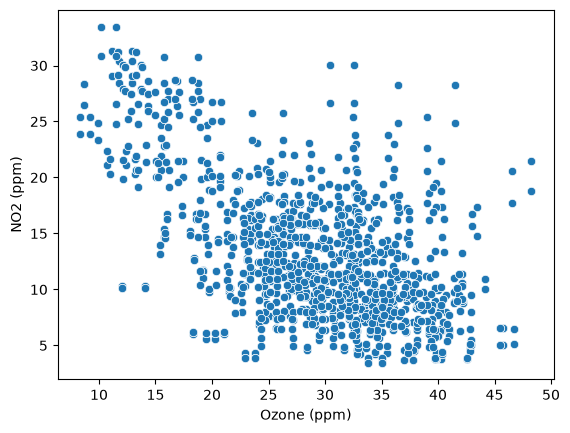

In [22]:
sns.scatterplot(data=O3_NO2, x=O3_NO2["Ozone"], y=O3_NO2["NO2"])
plt.xlabel('Ozone (ppm)')
plt.ylabel('NO2 (ppm)')

In [18]:
print('Type of df: ', type(O3_NO2))
print('Type of df[x]: ', type(O3_NO2['Ozone']))

Type of df:  <class 'pandas.DataFrame'>
Type of df[x]:  <class 'pandas.Series'>


In [19]:
xVal = np.array(O3_NO2['Ozone']).reshape((-1,1))
yVal = np.array(O3_NO2['NO2'])

print('Type of xVal: ', type(xVal))
print('Type of yVal: ', type(yVal))

Type of xVal:  <class 'numpy.ndarray'>
Type of yVal:  <class 'numpy.ndarray'>


In [20]:
reg = linear_model.LinearRegression() # this creates a regression object. creates the space for a linear model to be put into. 
reg.fit(xVal,yVal) # in the .fit method that does the optimization (via OSL), using the arrays we just made of x and y

print("Coefficients: \n", reg.coef_)
print("Intercept: \n", reg.intercept_)

Coefficients: 
 [-0.45504639]
Intercept: 
 26.560677497509772


Text(0, 0.5, 'NO2 (ppm)')

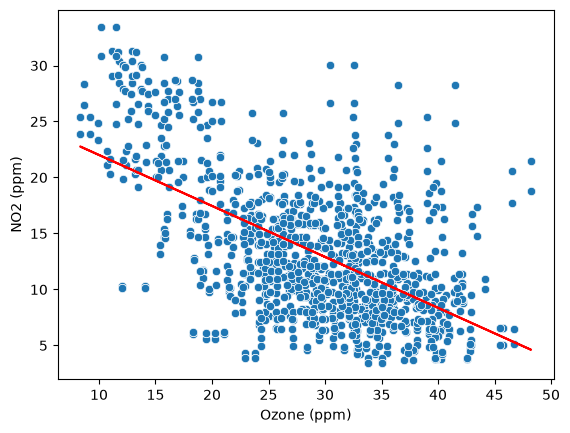

In [23]:
yPred = reg.predict(xVal)

O3_NO2['yPred'] = yPred
sns.scatterplot(data=O3_NO2, x="Ozone", y="NO2")
plt.plot(O3_NO2['Ozone'], O3_NO2['yPred'], color='r')
plt.xlabel('Ozone (ppm)')
plt.ylabel('NO2 (ppm)')

In [31]:
mean_squared_error(O3_NO2['NO2'],O3_NO2['yPred'])

25.627316492427337

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(xVal, yVal, test_size=0.20) # xVal and yVal are our x and y values

In [25]:
reg2 = linear_model.LinearRegression() # need to make a new fit. 
reg2.fit(X_train,y_train)
print("Coefficients: \n", reg2.coef_)
print("Intercept: \n", reg2.intercept_)

Coefficients: 
 [-0.44599132]
Intercept: 
 26.309142739629074


In [26]:
X_test.ravel() 

array([18.917, 14.917, 11.542, 32.588, 31.412, 11.75 , 22.   , 15.471,
       34.353, 36.   , 27.235, 23.167, 33.529, 38.647, 25.625, 46.588,
       23.542, 39.471, 41.941, 31.882, 24.042, 33.118, 36.042, 35.958,
       32.304, 32.647, 32.588, 13.294, 29.625, 26.353, 25.792, 26.417,
       45.75 , 26.417, 27.118, 29.75 , 33.75 , 27.375, 20.7  , 12.833,
       30.375, 29.133, 35.765, 19.647, 33.75 , 13.417, 12.882, 37.75 ,
       38.083, 40.167, 40.412, 28.333, 32.917, 28.471, 29.5  , 32.529,
       37.882, 25.765, 34.417, 35.529, 37.792, 28.706, 37.412, 33.706,
       34.118, 32.588, 33.588, 28.833, 41.471, 35.042, 23.375, 36.529,
       25.625, 34.333, 34.167, 15.417, 27.824, 27.   , 25.824, 23.833,
       32.917, 37.941, 11.667, 28.833, 14.375, 11.529, 42.118, 36.176,
       34.792, 39.417, 35.   , 27.5  , 19.583, 30.647, 14.917, 32.353,
       20.7  , 32.588, 22.941, 18.583, 39.048, 21.353, 35.056, 32.235,
       36.588, 40.294, 34.765, 36.941, 29.   , 35.042, 32.588, 32.   ,
      

In [27]:
#Plot Test Data
df_test = pd.DataFrame({'x' : X_test.ravel(), 'y' : y_test.ravel()})
df_test['yPred'] = reg2.predict(X_test)

Text(0, 0.5, 'NO2 (ppm)')

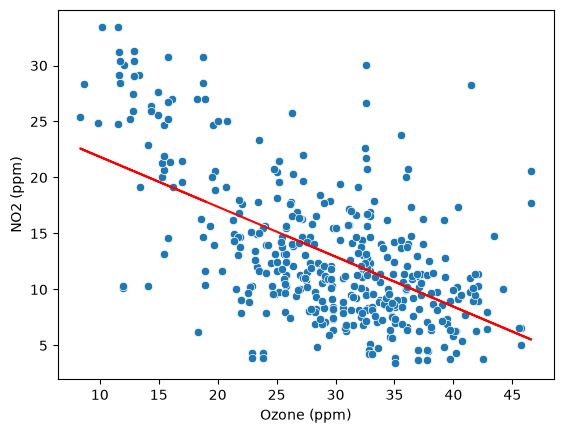

In [29]:
sns.scatterplot(data=df_test, x="x", y="y")
plt.plot(df_test['x'], df_test['yPred'], color='r')
plt.xlabel('Ozone (ppm)')
plt.ylabel('NO2 (ppm)')

In [30]:
mean_squared_error(df_test['y'],df_test['yPred'])

25.140116705218592

2. Test error: The MSE is 25ppm^2 so the error is 5ppm. 

I think the linear model worked pretty well. It visually makes sense, the error (loss term) is 5 when the range of y values is 0-35 ish? And the MSE is similar to the error I got from the training data. 

## CO2

In [33]:
df_CO2

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
786,2023,9,2023.7083,418.51,421.96,18,0.30,0.14
787,2023,10,2023.7917,418.82,422.12,27,0.47,0.17
788,2023,11,2023.8750,420.46,422.43,21,0.91,0.38
789,2023,12,2023.9583,421.86,422.56,20,0.70,0.30


In [47]:
df_CO2_b4_2000 = df_CO2[df_CO2['decimal date']<2000]
df_CO2_after_2000 = df_CO2[df_CO2['decimal date']>2000]

In [35]:
df_CO2_b4_2000

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
497,1999,8,1999.6250,367.06,368.63,25,0.38,0.14
498,1999,9,1999.7083,364.95,368.28,28,0.74,0.27
499,1999,10,1999.7917,365.52,368.80,31,0.28,0.10
500,1999,11,1999.8750,366.88,368.86,28,0.25,0.09


Text(0, 0.5, 'Average CO2 (ppm)')

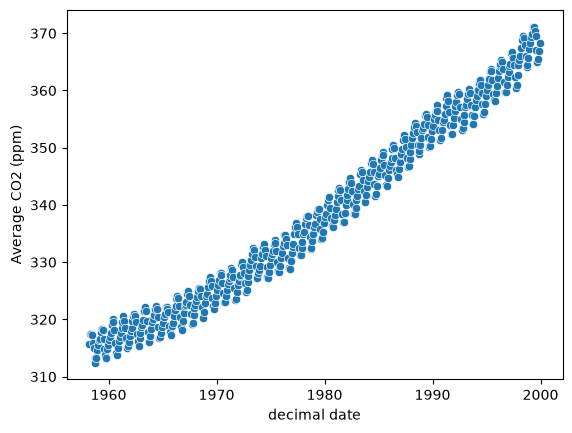

In [44]:
sns.scatterplot(data= df_CO2_b4_2000, x='decimal date', y='average')
plt.ylabel('Average CO2 (ppm)')

In [43]:
xVal_CO2 = np.array(df_CO2_b4_2000['decimal date']).reshape((-1,1))
yVal_CO2 = np.array(df_CO2_b4_2000['average'])

reg_co2 = linear_model.LinearRegression() # this creates a regression object. creates the space for a linear model to be put into. 
reg_co2.fit(xVal_CO2,yVal_CO2) # in the .fit method that does the optimization (via OSL), using the arrays we just made of x and y


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.32]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2281
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[270.6]


Text(0, 0.5, 'Average CO2 (ppm)')

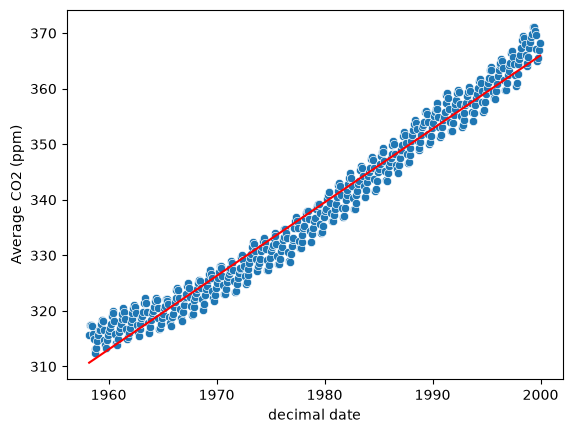

In [56]:
yPred_CO2 = reg_co2.predict(xVal_CO2)

df_CO2_b4_2000['yPred'] = yPred_CO2

sns.scatterplot(data=df_CO2_b4_2000, x="decimal date", y="average")
plt.plot(df_CO2_b4_2000['decimal date'], df_CO2_b4_2000['yPred'], color='r')
plt.xlabel('decimal date')
plt.ylabel('Average CO2 (ppm)')

In [59]:
mean_squared_error(df_CO2_b4_2000['average'],df_CO2_b4_2000['yPred'])

7.428737725453366

In [48]:
df_CO2_after_2000

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
502,2000,1,2000.0417,369.45,369.24,26,0.48,0.18
503,2000,2,2000.1250,369.71,368.99,19,0.48,0.21
504,2000,3,2000.2083,370.75,369.24,30,0.47,0.16
505,2000,4,2000.2917,371.98,369.44,27,0.58,0.21
506,2000,5,2000.3750,371.75,368.87,28,0.53,0.19
...,...,...,...,...,...,...,...,...
786,2023,9,2023.7083,418.51,421.96,18,0.30,0.14
787,2023,10,2023.7917,418.82,422.12,27,0.47,0.17
788,2023,11,2023.8750,420.46,422.43,21,0.91,0.38
789,2023,12,2023.9583,421.86,422.56,20,0.70,0.30


In [52]:
type(df_CO2_b4_2000['decimal date'])

pandas.Series

In [60]:
X_train = np.array(df_CO2_b4_2000['decimal date']).reshape((-1,1))
y_train = np.array(df_CO2_b4_2000['average'])

X_test = np.array(df_CO2_after_2000['decimal date']).reshape((-1,1))
y_test = np.array(df_CO2_after_2000['average'])
 
reg2 = linear_model.LinearRegression() 
reg2.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.32]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2281
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[270.6]


In [61]:
#Plot Test Data
df_test = pd.DataFrame({'x' : X_test.ravel(), 'y' : y_test.ravel()})
df_test['yPred'] = reg2.predict(X_test)

Text(0, 0.5, 'CO2 (ppm)')

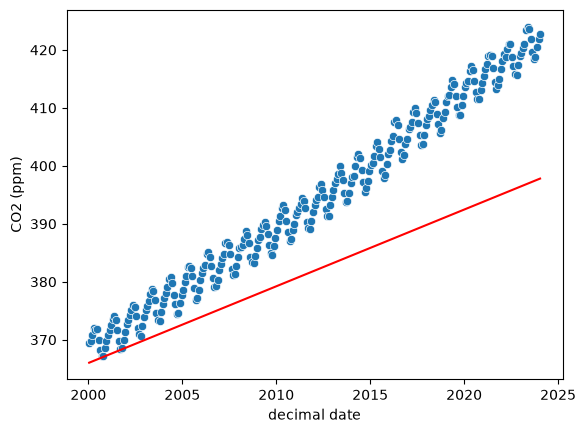

In [62]:
sns.scatterplot(data=df_test, x="x", y="y")
plt.plot(df_test['x'], df_test['yPred'], color='r')
plt.xlabel('decimal date')
plt.ylabel('CO2 (ppm)')

In [63]:
mean_squared_error(df_test['y'],df_test['yPred'])

200.24617110972463

The linear model did not do well. Visually the red line is way off of the blue data, showing the model doesnt fit with with the test data. Also the error is much larger (200 ppm CO2) compared to the MSE of the training data (7 ppm CO2). 